# Features Generation Validation Analysis: Variability and Accuracy of the Predictions

In [26]:
import os
import json
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import sys 


In [27]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..')
labeling_dir = os.path.join(project_path, 'data', 'labeled_samples')
val_sample_path = os.path.join(labeling_dir, '03a_validation_sample.json')
validation_results_dir = os.path.join(project_path, 'data', 'validation_results')
val_results_path = os.path.join(validation_results_dir, 'validation_results_content_relevance_score.json')

sys.path.insert(0, project_path)
from src.feature_engineering_utils import load_labeled_sample

In [28]:
df_val = load_labeled_sample(val_sample_path)

with open(val_results_path, "r", encoding="utf-8") as f:
    val_results = json.load(f)



In [29]:
def get_dfs_validation_analysis(df_val, val_results, feature_name):

    true_values_df = df_val[['comment_id', feature_name]]

    iter_pred_values_dict = val_results['llm_metadata']['iterations_predicted_values']
    iter_pred_values_df_wide = pl.DataFrame(iter_pred_values_dict)
    comment_ids = list(iter_pred_values_dict.keys())
    predicted_values = list(iter_pred_values_dict.values())
    iter_pred_values_df_long = pl.DataFrame({'comment_id': comment_ids, 'predicted_values': predicted_values})

    true_predicted_values_df = true_values_df.join(
        iter_pred_values_df_long, on='comment_id', how='inner'
    ).with_columns(
        predicted_values_mean = pl.col('predicted_values').list.mean(),
        predicted_values_std = pl.col('predicted_values').list.std(),
        predicted_values_q25 = pl.col('predicted_values').list.eval(pl.element().quantile(0.25)).list.first(),
        predicted_values_q75 = pl.col('predicted_values').list.eval(pl.element().quantile(0.75)).list.first(),
        predicted_values_range = 5 - 0 # Theoretical range 
        # predicted_values_range = pl.col('predicted_values').list.max() - pl.col('predicted_values').list.min() # Observed range
    ).with_columns(
        predicted_values_cv_std = (pl.col('predicted_values_std') / pl.col('predicted_values_mean').abs()).fill_nan(None),
        predicted_values_cv_quantiles = ((pl.col('predicted_values_q75') - pl.col('predicted_values_q25')) / (pl.col('predicted_values_q75') + pl.col('predicted_values_q25'))).fill_nan(None),
        predicted_values_cv_range = (pl.col('predicted_values_std') / pl.col('predicted_values_range')).fill_nan(None)
    ).sort(
        by='predicted_values_mean'
    )

    df_plot = iter_pred_values_df_wide.unpivot(
        variable_name="comment_id", 
        value_name="prediction"
    ).sort(
        by='prediction'
    ).join(true_values_df, on='comment_id', how='inner'
    ).join(true_predicted_values_df[['comment_id', 'predicted_values_mean', 'predicted_values_std']], on='comment_id', how='inner'
    )

    return true_predicted_values_df, df_plot

In [30]:
feature_name = 'content_relevance_score'

true_predicted_values_df, df_plot = get_dfs_validation_analysis(df_val, val_results, feature_name)

In [31]:
true_predicted_values_df

comment_id,content_relevance_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_q25,predicted_values_q75,predicted_values_range,predicted_values_cv_std,predicted_values_cv_quantiles,predicted_values_cv_range
str,i64,list[i64],f64,f64,f64,f64,i32,f64,f64,f64
"""nku4zpn""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""m6e3w4q""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""njks7hu""",5,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""ncmr4po""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""mz3l0jp""",1,"[1, 0, 1]",0.666667,0.57735,1.0,1.0,5,0.866025,0.0,0.11547
…,…,…,…,…,…,…,…,…,…,…
"""nh1m4vm""",5,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0
"""njudcg7""",5,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0
"""n5bd4bo""",5,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0


In [32]:
df_plot

comment_id,prediction,content_relevance_score,predicted_values_mean,predicted_values_std
str,i64,i64,f64,f64
"""nku4zpn""",0,0,0.0,0.0
"""nku4zpn""",0,0,0.0,0.0
"""nku4zpn""",0,0,0.0,0.0
"""m6e3w4q""",0,0,0.0,0.0
"""m6e3w4q""",0,0,0.0,0.0
…,…,…,…,…
"""nkjmluy""",5,5,5.0,0.0
"""njv8x1o""",5,5,5.0,0.0
"""njv8x1o""",5,5,5.0,0.0


In [33]:
print('Métricas de Variabilidad:')

print(f'Coeficiente de variación basado en desviación estandar: {round(true_predicted_values_df['predicted_values_cv_std'].mean() * 100, 2)}%')

print(f'Coeficiente de variación basado en cuartiles 25 y 75: {round(true_predicted_values_df['predicted_values_cv_quantiles'].mean() * 100, 2)}%')

print(f'Coeficiente de variación basado en rango: {round(true_predicted_values_df['predicted_values_cv_range'].mean(), 2)}%')

Métricas de Variabilidad:
Coeficiente de variación basado en desviación estandar: 7.42%
Coeficiente de variación basado en cuartiles 25 y 75: 1.71%
Coeficiente de variación basado en rango: 0.04%


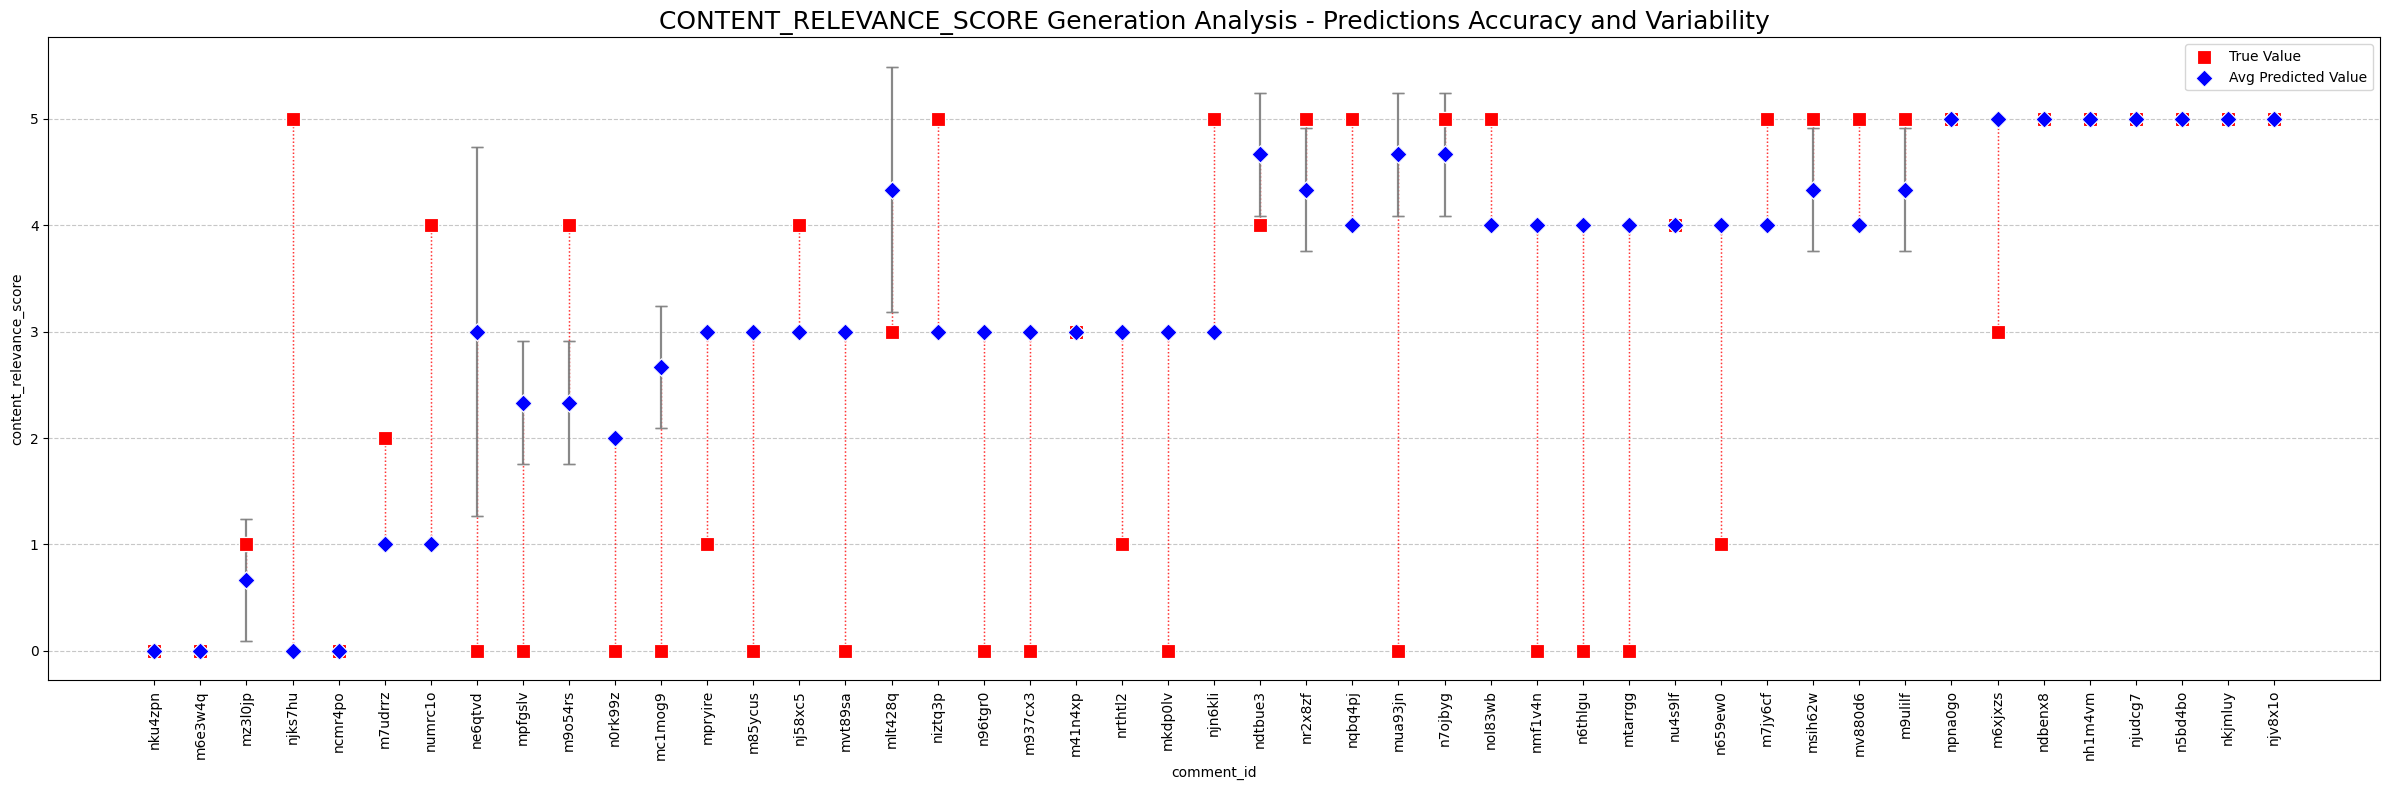

In [36]:
plt.show()

plt.figure(figsize=(24, 8))

# C. "Ground Truth" (El valor real - PUNTO ROJO)
sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y=feature_name,
    color="red",
    s=110,            # Tamaño grande
    marker="s",       # Forma de diamante
    label="True Value",
    zorder=10         # Para que aparezca encima de todo
)

plt.errorbar(
    x=df_plot["comment_id"],             # Misma X
    y=df_plot["predicted_values_mean"],  # Misma Y (centro de la barra)
    yerr=df_plot["predicted_values_std"],# <--- AQUÍ VA LA LONGITUD DE LA BARRA (STD)
    fmt='none',      # 'none' significa: "no dibujes puntos, solo las líneas"
    ecolor='gray',   # Color de la barra (gris para no distraer)
    elinewidth=1.5,  # Grosor de la línea
    capsize=4,       # "Topes" horizontales en los extremos de la barra
    alpha=0.6,       # Transparencia
    zorder=5         # Nivel de capa (detrás de los puntos del scatter)
)

sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y="predicted_values_mean",
    color="blue",
    s=75,            # Tamaño grande
    marker="D",       # Forma de diamante
    label="Avg Predicted Value",
    zorder=10         # Para que aparezca encima de todo
)

plt.vlines(
    x=df_plot["comment_id"],
    ymin=df_plot[feature_name],
    ymax=df_plot["predicted_values_mean"],
    colors='red',
    linestyles='dotted',
    alpha=0.4,
    linewidth=1,
    label='Residual Error'
)

plt.title(f"{feature_name.upper()} Generation Analysis - Predictions Accuracy and Variability", fontsize=18)
plt.xticks(rotation=90, fontsize=10) # Rotar etiquetas 90 grados
plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para ver mejor los niveles
plt.tight_layout()

plt.show()

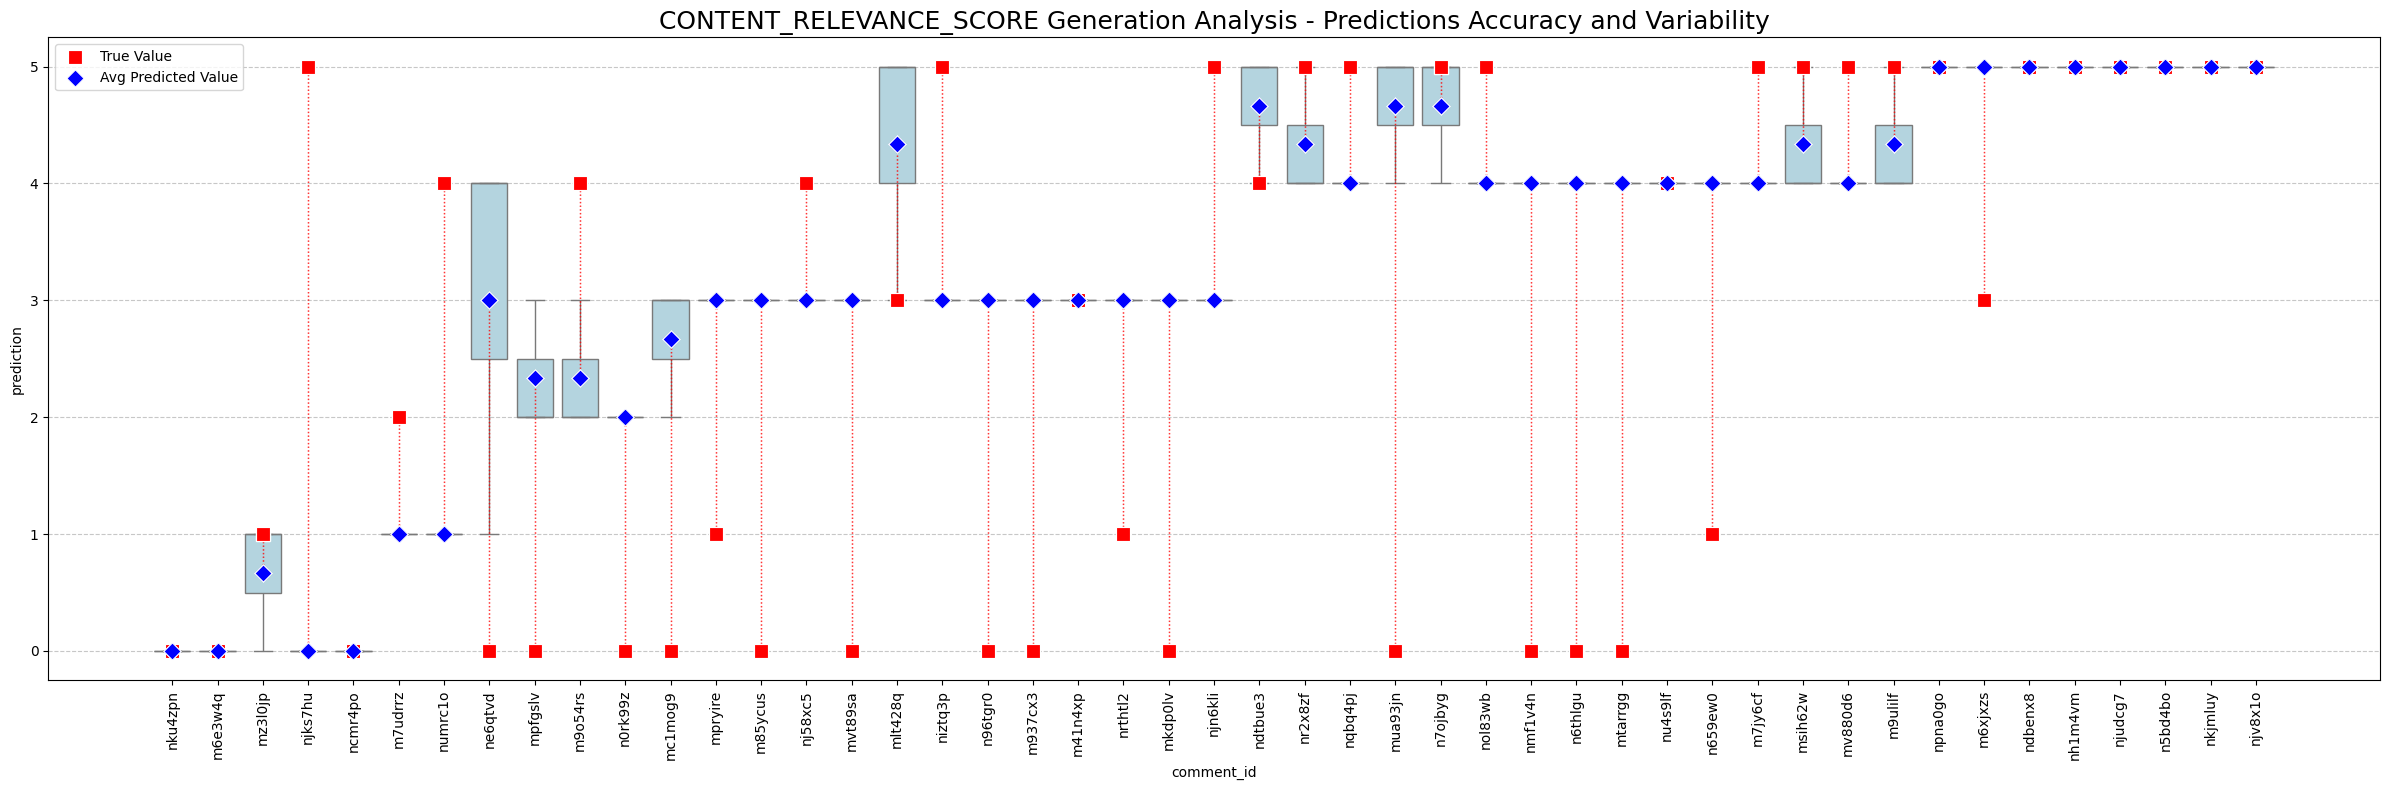

In [37]:
plt.figure(figsize=(24, 8))

# A. Boxplot de las Predicciones (Ordenado)
sns.boxplot(
    data=df_plot,
    x="comment_id",
    y="prediction",
    color="lightblue",
    showfliers=True
)

# C. "Ground Truth" (El valor real - PUNTO ROJO)
sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y=feature_name,
    color="red",
    s=110,            # Tamaño grande
    marker="s",       # Forma de diamante
    label="True Value",
    zorder=10         # Para que aparezca encima de todo
)

sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y="predicted_values_mean",
    color="blue",
    s=75,            # Tamaño grande
    marker="D",       # Forma de diamante
    label="Avg Predicted Value",
    zorder=10         # Para que aparezca encima de todo
)

plt.vlines(
    x=df_plot["comment_id"],
    ymin=df_plot[feature_name],
    ymax=df_plot["predicted_values_mean"],
    colors='red',
    linestyles='dotted',
    alpha=0.4,
    linewidth=1,
    label='Residual Error'
)

plt.title(f"{feature_name.upper()} Generation Analysis - Predictions Accuracy and Variability", fontsize=18)
plt.xticks(rotation=90, fontsize=10) # Rotar etiquetas 90 grados
plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para ver mejor los niveles
plt.tight_layout()